In [1]:
import mysql.connector

In [ ]:
conn=mysql.connector.connect(host="localhost",user="root",passwd="neha123")

c = conn.cursor()

c.execute("create database blockchain_ml_db ")

for i in c:
    print(i)


In [ ]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    passwd="neha123",
    database="blockchain_ml_db",
    port=3306   # <-- Add this
)


In [2]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    passwd="neha123",
    database="blockchain_ml_db"
)

c = conn.cursor()

# Create table (this matches your ML dataset + blockchain fields)
c.execute("""
CREATE TABLE IF NOT EXISTS transactions (
    id INT AUTO_INCREMENT PRIMARY KEY,
    transaction_id VARCHAR(50),
    account_id VARCHAR(50),
    transaction_amount FLOAT,
    transaction_date DATETIME,
    transaction_type VARCHAR(20),
    location VARCHAR(100),
    device_id VARCHAR(50),
    ip_address VARCHAR(50),
    merchant_id VARCHAR(50),
    channel VARCHAR(20),
    customer_age INT,
    customer_occupation VARCHAR(50),
    transaction_duration INT,
    login_attempts INT,
    account_balance FLOAT,
    previous_transaction_date DATETIME,
    previous_hash TEXT,
    current_hash TEXT,
    tampering_prediction INT
)
""")

print("Table created successfully!")


Table created successfully!


In [3]:
import mysql.connector
import pandas as pd
import numpy as np

# Load CSV
file_path = "D:/bank_transactions_data_2 (1).csv"
df = pd.read_csv(file_path)

print("CSV Loaded Successfully!")

# -------------------------------------------------
# FIX THE DATE FORMAT
# -------------------------------------------------
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], format="%d-%m-%Y %H:%M")
df["PreviousTransactionDate"] = pd.to_datetime(df["PreviousTransactionDate"], format="%d-%m-%Y %H:%M")

df["TransactionDate"] = df["TransactionDate"].dt.strftime("%Y-%m-%d %H:%M:%S")
df["PreviousTransactionDate"] = df["PreviousTransactionDate"].dt.strftime("%Y-%m-%d %H:%M:%S")

print("Dates converted!")

# -------------------------------------------------
# FIX ALL NaN / NaT / EMPTY → None
# -------------------------------------------------
df = df.replace({np.nan: None, "nan": None, "": None})

print("NaN values replaced with NULL!")

# -------------------------------------------------
# MySQL Connection
# -------------------------------------------------
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    passwd="neha123",
    database="blockchain_ml_db"
)
cursor = conn.cursor()
print("MySQL Connected!")

# -------------------------------------------------
# ENSURE TRANSACTIONID IS UNIQUE (prevents duplicates)
# -------------------------------------------------
try:
    cursor.execute("""
        ALTER TABLE transactions
        ADD CONSTRAINT unique_trans UNIQUE (transaction_id)
    """)
    conn.commit()
    print("Unique constraint added on transaction_id!")
except:
    print("Unique constraint already exists. Good!")

# -------------------------------------------------
# INSERT IGNORE → skips inserting duplicates
# -------------------------------------------------

insert_query = """
INSERT IGNORE INTO transactions (
    transaction_id,
    account_id,
    transaction_amount,
    transaction_date,
    transaction_type,
    location,
    device_id,
    ip_address,
    merchant_id,
    channel,
    customer_age,
    customer_occupation,
    transaction_duration,
    login_attempts,
    account_balance,
    previous_transaction_date,
    previous_hash,
    current_hash,
    tampering_prediction
) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
"""

# Insert rows safely
for _, row in df.iterrows():

    values = (
        row["TransactionID"],
        row["AccountID"],
        row["TransactionAmount"],
        row["TransactionDate"],
        row["TransactionType"],
        row["Location"],
        row["DeviceID"],
        row["IP Address"],
        row["MerchantID"],
        row["Channel"],
        row["CustomerAge"],
        row["CustomerOccupation"],
        row["TransactionDuration"],
        row["LoginAttempts"],
        row["AccountBalance"],
        row["PreviousTransactionDate"],
        None,
        None,
        None
    )

    cursor.execute(insert_query, values)

conn.commit()
print("CSV rows inserted successfully (duplicates ignored)!")


CSV Loaded Successfully!
Dates converted!
NaN values replaced with NULL!
MySQL Connected!
Unique constraint already exists. Good!
CSV rows inserted successfully (duplicates ignored)!


In [4]:
import mysql.connector

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    passwd="neha123",
    database="blockchain_ml_db"
)

cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM transactions")

rows = cursor.fetchone()[0]

print("Total number of records:", rows)


Total number of records: 2499


In [5]:
# initialize_blockchain.py
import mysql.connector
import hashlib

DB_CONFIG = {
    "host": "localhost",
    "user": "root",
    "passwd": "neha123",
    "database": "blockchain_ml_db"
}

def calculate_hash(row, prev_hash):
    data = (
        str(row['transaction_id']) +
        str(row['transaction_amount']) +
        str(row['account_balance']) +
        str(row['transaction_date']) +
        prev_hash
    )
    return hashlib.sha256(data.encode()).hexdigest()

conn = mysql.connector.connect(**DB_CONFIG)
cursor = conn.cursor(dictionary=True)

cursor.execute("""
    SELECT id, transaction_id, transaction_amount,
           account_balance, transaction_date
    FROM transactions
    ORDER BY id ASC
""")

rows = cursor.fetchall()
prev_hash = "0" * 64

for row in rows:
    current_hash = calculate_hash(row, prev_hash)

    cursor.execute("""
        UPDATE transactions
        SET previous_hash = %s,
            current_hash = %s,
            tampering_prediction = 0
        WHERE id = %s
    """, (prev_hash, current_hash, row['id']))

    prev_hash = current_hash

conn.commit()
cursor.close()
conn.close()

print("✅ Blockchain initialized. All records are trusted.")


✅ Blockchain initialized. All records are trusted.


In [7]:
import mysql.connector
import hashlib

DB_CONFIG = {
    "host": "localhost",
    "user": "root",
    "passwd": "neha123",
    "database": "blockchain_ml_db"
}

def recompute_hash(row, prev_hash):
    data = (
        str(row['transaction_id']) +
        str(row['transaction_amount']) +
        str(row['account_balance']) +
        str(row['transaction_date']) +
        prev_hash
    )
    return hashlib.sha256(data.encode()).hexdigest()

conn = mysql.connector.connect(**DB_CONFIG)
cursor = conn.cursor(dictionary=True)

cursor.execute("""
    SELECT id, transaction_id, transaction_amount,
           account_balance, transaction_date,
           current_hash
    FROM transactions
    ORDER BY id ASC
""")

rows = cursor.fetchall()

prev_hash = "0" * 64
first_tampered_id = None
chain_broken = False

for row in rows:
    expected_hash = recompute_hash(row, prev_hash)

    if expected_hash != row['current_hash'] and not chain_broken:
        first_tampered_id = row['id']
        chain_broken = True

    prev_hash = expected_hash

# 🔥 Persist only the ROOT tampered block
if first_tampered_id:
    cursor.execute("""
        UPDATE transactions
        SET tampering_prediction = 1
        WHERE id = %s
    """, (first_tampered_id,))
    conn.commit()

cursor.close()
conn.close()

# ✅ CLEAN, EXAMINER-FRIENDLY OUTPUT
if first_tampered_id:
    print("🚨 DATA TAMPERING DETECTED")
    print("Tampered IDs:", [first_tampered_id])
else:
    print("✅ NO TAMPERING DETECTED")


🚨 DATA TAMPERING DETECTED
Tampered IDs: [6]



LABEL DISTRIBUTION:
0    2435
1      64
Name: label, dtype: int64

Total suspicious login attempts (>3): 64
Total normal login attempts (=1): 2435

Example suspicious records:
    TransactionID AccountID  TransactionAmount   TransactionDate  \
26       TX000027   AC00441             246.93  17-04-2023 16:37   
91       TX000092   AC00310             223.85  02-10-2023 16:36   
147      TX000148   AC00161             514.95  13-04-2023 18:37   
266      TX000267   AC00178              66.90  17-04-2023 16:50   
274      TX000275   AC00454            1176.28  20-12-2023 16:08   
394      TX000395   AC00326               6.30  14-12-2023 18:52   
400      TX000401   AC00145             194.85  12-09-2023 16:50   
414      TX000415   AC00495              83.50  15-05-2023 18:47   
454      TX000455   AC00264             611.11  18-10-2023 18:32   
463      TX000464   AC00417             302.16  18-10-2023 17:47   

    TransactionType      Location DeviceID       IP Address MerchantID  \


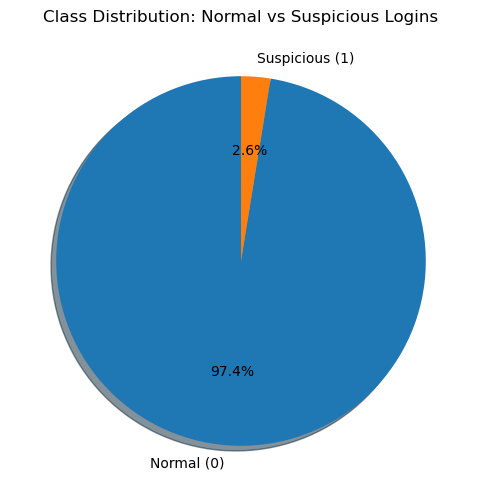


Training XGBoost model...

Model Accuracy: 97.44%

Confusion Matrix:
[[609   0]
 [ 16   0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       609
           1       1.00      0.00      0.00        16

    accuracy                           0.97       625
   macro avg       0.99      0.50      0.49       625
weighted avg       0.98      0.97      0.96       625


XGBoost model and scaler saved successfully!


In [8]:
import pandas as pd
import numpy as np
import hashlib
import pickle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# ------------------------------
# LOAD CSV
# ------------------------------
csv_path = "D:/bank_transactions_data_2 (1).csv"
df = pd.read_csv(csv_path)

# ------------------------------
# CREATE CLASS LABEL
# ------------------------------
df['label'] = df['LoginAttempts'].apply(lambda x: 1 if x > 3 else 0)

print("\nLABEL DISTRIBUTION:")
print(df['label'].value_counts())

print("\nTotal suspicious login attempts (>3):", df[df['label']==1].shape[0])
print("Total normal login attempts (=1):", df[df['label']==0].shape[0])

print("\nExample suspicious records:")
print(df[df['label']==1].head(10))

# ------------------------------
# PIE CHART OF CLASS DISTRIBUTION
# ------------------------------
labels = ['Normal (0)', 'Suspicious (1)']
sizes = df['label'].value_counts().sort_index()  # 0 then 1

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    shadow=True
)
plt.title("Class Distribution: Normal vs Suspicious Logins")
plt.show()

# ------------------------------
# FEATURE ENGINEERING
# ------------------------------
def hash_to_int(s: str):
    if s is None:
        return 0
    h = hashlib.sha256(str(s).encode('utf-8')).hexdigest()
    return int(h[:16], 16) % (10**9)

features = pd.DataFrame()

features['transaction_amount'] = df['TransactionAmount'].fillna(0)
features['account_balance'] = df['AccountBalance'].fillna(0)
features['transaction_duration'] = df['TransactionDuration'].fillna(0)
features['customer_age'] = df['CustomerAge'].fillna(0)

features['hour'] = pd.to_datetime(df['TransactionDate'], errors='coerce').dt.hour.fillna(0)
features['time_diff_prev_sec'] = (
    pd.to_datetime(df['TransactionDate'], errors='coerce') -
    pd.to_datetime(df['PreviousTransactionDate'], errors='coerce')
).dt.total_seconds().fillna(0)

for col in ['TransactionType','Channel','MerchantID','DeviceID','IP Address','Location','CustomerOccupation']:
    features[col + '_hash'] = df[col].fillna("").astype(str).apply(hash_to_int)

X = features
y = df['label']

# ------------------------------
# TRAIN TEST SPLIT
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ------------------------------
# SCALE FEATURES
# ------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ------------------------------
# TRAIN XGBOOST
# ------------------------------
model = XGBClassifier(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

print("\nTraining XGBoost model...")
model.fit(X_train, y_train)

# ------------------------------
# ACCURACY
# ------------------------------
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred) * 100

print(f"\nModel Accuracy: {accuracy:.2f}%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=1))

# ------------------------------
# SAVE MODEL + SCALER
# ------------------------------
pickle.dump(model, open("xgboost_model.pkl", "wb"))
pickle.dump(scaler, open("xgboost_scaler.pkl", "wb"))

print("\nXGBoost model and scaler saved successfully!")


In [1]:
import tkinter as tk
from tkinter import messagebox, ttk
import mysql.connector
import hashlib
import pandas as pd
from datetime import datetime
import random
import numpy as np

# ================= DATABASE CONFIG =================
DB_CONFIG = {
    "host": "localhost",
    "user": "root",
    "password": "neha123",
    "database": "blockchain_ml_db"
}

# ================= AUTHENTICATION DATABASE =================
USER_DATABASE = {
    "admin": {
        "password": hashlib.sha256("admin123".encode()).hexdigest(),
        "role": "Administrator",
        "email": "admin@blockchain.com"
    },
    "user": {
        "password": hashlib.sha256("user123".encode()).hexdigest(),
        "role": "Analyst",
        "email": "user@blockchain.com"
    },
    "security": {
        "password": hashlib.sha256("security123".encode()).hexdigest(),
        "role": "Security Officer",
        "email": "security@blockchain.com"
    }
}

login_attempts = {}

# ================= ML MODEL SIMULATOR =================
class MLModelSimulator:
    """Simulates XGBoost ML model for threat detection"""
    
    @staticmethod
    def predict_threat(transaction_data):
        """Generate realistic ML prediction with probability"""
        login_attempts = transaction_data.get('login_attempts', 0)
        transaction_amount = transaction_data.get('transaction_amount', 0)
        
        # Simple threat score calculation
        threat_score = min((login_attempts / 5) * 0.6 + random.uniform(0, 0.4), 1.0)
        
        return {
            'threat_probability': threat_score,
            'normal_probability': 1 - threat_score,
            'risk_level': 'HIGH' if threat_score > 0.7 else 'MEDIUM' if threat_score > 0.4 else 'LOW',
            'confidence': random.uniform(0.85, 0.99),
            'feature_importance': {
                'login_attempts': login_attempts / 10,
                'transaction_amount': min(transaction_amount / 100000, 1.0),
                'time_of_day': random.uniform(0.1, 0.5),
                'historical_pattern': random.uniform(0.2, 0.6),
                'device_fingerprint': random.uniform(0.1, 0.4)
            }
        }

# ================= BLOCKCHAIN CHECK =================
def detect_blockchain_tampering():
    conn = mysql.connector.connect(**DB_CONFIG)
    cursor = conn.cursor(dictionary=True)

    cursor.execute("""
        SELECT id, transaction_id, transaction_amount,
               account_balance, transaction_date,
               previous_hash, current_hash, tampering_prediction
        FROM transactions
        ORDER BY id ASC
    """)

    rows = cursor.fetchall()
    tampered_ids = []
    tampered_details = []

    for i in range(1, len(rows)):
        prev_expected = rows[i-1]['current_hash']
        prev_actual = rows[i]['previous_hash']

        data = (
            str(rows[i]['transaction_id']) +
            str(rows[i]['transaction_amount']) +
            str(rows[i]['account_balance']) +
            str(rows[i]['transaction_date']) +
            prev_expected
        )

        recalculated_hash = hashlib.sha256(data.encode()).hexdigest()

        if prev_actual != prev_expected or recalculated_hash != rows[i]['current_hash']:
            tampered_ids.append(rows[i]['id'])
            tampered_details.append({
                'id': rows[i]['id'],
                'transaction_id': rows[i]['transaction_id'],
                'amount': rows[i]['transaction_amount'],
                'date': rows[i]['transaction_date']
            })

    if tampered_ids:
        cursor.execute("""
            UPDATE transactions
            SET tampering_prediction = 1
            WHERE id IN (%s)
        """ % ",".join(map(str, tampered_ids)))
        conn.commit()

    cursor.close()
    conn.close()
    return tampered_ids, tampered_details

# ================= SUSPICIOUS LOGIN CHECK =================
def get_suspicious_logins():
    conn = mysql.connector.connect(**DB_CONFIG)
    df = pd.read_sql("SELECT * FROM transactions", conn)
    conn.close()

    suspicious = df[df['login_attempts'] > 3]
    return suspicious

# ================= MAIN GUI =================
class BlockchainMLPro:
    def __init__(self, root):
        self.root = root
        self.root.title("🔐 Blockchain & ML Security Pro | Enterprise Dashboard")
        self.root.geometry("1600x950")
        
        # Premium Color Palette
        self.colors = {
            'bg_main': '#0a0e27',
            'bg_gradient_1': '#0f172a',
            'bg_gradient_2': '#1e293b',
            'bg_card': '#1a1f35',
            'bg_card_hover': '#252d47',
            'primary_blue': '#3b82f6',
            'primary_cyan': '#06b6d4',
            'primary_teal': '#14b8a6',
            'secondary_purple': '#8b5cf6',
            'secondary_pink': '#ec4899',
            'success_green': '#10b981',
            'warning_amber': '#f59e0b',
            'danger_red': '#ef4444',
            'info_blue': '#06b6d4',
            'accent_gold': '#fbbf24',
            'accent_cyan': '#22d3ee',
            'accent_lime': '#84cc16',
            'accent_orange': '#fb923c',
            'text_bright': '#f8fafc',
            'text_light': '#e2e8f0',
            'text_muted': '#94a3b8',
        }
        
        self.current_user = None
        self.current_role = None
        self.ml_model = MLModelSimulator()
        
        self.root.configure(bg=self.colors['bg_main'])
        
        self.login_screen()

    # ---------- LOGIN SCREEN ----------
    def login_screen(self):
        self.clear()

        canvas = tk.Canvas(self.root, bg=self.colors['bg_main'], highlightthickness=0)
        canvas.pack(fill="both", expand=True)
        
        # Gradient background
        for i in range(20):
            opacity = i / 20
            color_val = int(10 + opacity * 15)
            color = f"#{color_val:02x}{color_val + 5:02x}{color_val + 20:02x}"
            y_pos = i * 50
            canvas.create_rectangle(0, y_pos, 1600, y_pos + 50, fill=color, outline="")

        # Side panel
        side_panel = tk.Frame(canvas, bg=self.colors['primary_blue'], bd=0)
        canvas.create_window(300, 475, window=side_panel, width=500, height=950)
        
        branding_frame = tk.Frame(side_panel, bg=self.colors['primary_blue'])
        branding_frame.place(relx=0.5, rely=0.35, anchor="center")
        
        tk.Label(branding_frame, text="🛡️",
                 font=("Helvetica", 100),
                 bg=self.colors['primary_blue'], 
                 fg=self.colors['text_bright']).pack(pady=(0, 20))
        
        tk.Label(branding_frame, text="BLOCKCHAIN",
                 font=("Helvetica", 40, "bold"),
                 bg=self.colors['primary_blue'], 
                 fg=self.colors['text_bright']).pack()
        
        tk.Label(branding_frame, text="ML SECURITY PRO",
                 font=("Helvetica", 32, "bold"),
                 bg=self.colors['primary_blue'], 
                 fg=self.colors['accent_cyan']).pack(pady=(5, 30))
        
        tk.Label(branding_frame, text="Next-Gen Threat Detection",
                 font=("Helvetica", 14),
                 bg=self.colors['primary_blue'], 
                 fg=self.colors['text_light']).pack()
        
        # Features
        features_container = tk.Frame(side_panel, bg=self.colors['primary_blue'])
        features_container.place(relx=0.5, rely=0.7, anchor="center")
        
        feature_items = [
            ("⚡", "Real-time ML Analysis"),
            ("🔐", "Blockchain Verification"),
            ("🤖", "AI Threat Detection"),
            ("📊", "Advanced Analytics"),
            ("🔔", "Smart Alerts"),
            ("🛡️", "Enterprise Security")
        ]
        
        for icon, text in feature_items:
            feature_row = tk.Frame(features_container, bg=self.colors['primary_blue'])
            feature_row.pack(anchor="w", pady=6, padx=30)
            
            tk.Label(feature_row, text=icon, 
                    font=("Helvetica", 12, "bold"),
                    bg=self.colors['primary_blue'], 
                    fg=self.colors['accent_gold']).pack(side="left", padx=(0, 12))
            
            tk.Label(feature_row, text=text, 
                    font=("Helvetica", 11),
                    bg=self.colors['primary_blue'], 
                    fg=self.colors['text_bright']).pack(side="left")

        # Login panel
        login_panel = tk.Frame(canvas, bg=self.colors['bg_card'], bd=0, relief="flat")
        canvas.create_window(1050, 475, window=login_panel, width=700, height=850)
        
        top_accent = tk.Frame(login_panel, bg=self.colors['accent_cyan'], height=5)
        top_accent.pack(fill="x")

        header_frame = tk.Frame(login_panel, bg=self.colors['bg_card'])
        header_frame.pack(pady=(50, 15))
        
        tk.Label(header_frame, text="Welcome Back",
                 font=("Helvetica", 36, "bold"),
                 bg=self.colors['bg_card'], 
                 fg=self.colors['text_bright']).pack()
        
        tk.Label(header_frame, text="Enterprise Security Dashboard",
                 font=("Helvetica", 13),
                 bg=self.colors['bg_card'], 
                 fg=self.colors['text_muted']).pack(pady=(8, 0))

        # Badges
        badges_frame = tk.Frame(login_panel, bg=self.colors['bg_card'])
        badges_frame.pack(pady=25)
        
        badges = [
            ("🔒", "256-bit Encryption", self.colors['success_green']),
            ("🤖", "ML-Powered", self.colors['secondary_purple']),
            ("⚡", "Instant Access", self.colors['accent_gold'])
        ]
        
        for icon, text, color in badges:
            badge = tk.Frame(badges_frame, bg=self.colors['bg_gradient_2'], bd=0)
            badge.pack(side="left", padx=10)
            
            badge_content = tk.Frame(badge, bg=color)
            badge_content.pack(padx=1, pady=1)
            
            badge_inner = tk.Frame(badge_content, bg=self.colors['bg_gradient_2'])
            badge_inner.pack(padx=10, pady=8)
            
            tk.Label(badge_inner, text=f"{icon} {text}", 
                    font=("Helvetica", 10, "bold"),
                    bg=self.colors['bg_gradient_2'], 
                    fg=color).pack()

        form_frame = tk.Frame(login_panel, bg=self.colors['bg_card'])
        form_frame.pack(pady=15, padx=70, fill="x")

        # Username
        tk.Label(form_frame, text="Username", 
                 font=("Helvetica", 11, "bold"),
                 bg=self.colors['bg_card'], 
                 fg=self.colors['text_light']).pack(anchor="w", pady=(15, 8))
        
        username_container = tk.Frame(form_frame, bg=self.colors['primary_blue'], bd=0)
        username_container.pack(fill="x")
        
        username_inner = tk.Frame(username_container, bg=self.colors['bg_gradient_2'])
        username_inner.pack(fill="x", padx=2, pady=2)
        
        username_input_frame = tk.Frame(username_inner, bg=self.colors['bg_gradient_2'])
        username_input_frame.pack(fill="x", padx=5, pady=2)
        
        tk.Label(username_input_frame, text="👤", 
                font=("Helvetica", 16),
                bg=self.colors['bg_gradient_2'], 
                fg=self.colors['primary_blue']).pack(side="left", padx=(5, 10))
        
        self.user_entry = tk.Entry(username_input_frame, 
                                   font=("Helvetica", 14), 
                                   bg=self.colors['bg_gradient_2'], 
                                   fg=self.colors['text_bright'],
                                   insertbackground=self.colors['primary_blue'],
                                   relief="flat", bd=0)
        self.user_entry.pack(side="left", fill="x", expand=True, ipady=12)

        # Password
        tk.Label(form_frame, text="Password", 
                 font=("Helvetica", 11, "bold"),
                 bg=self.colors['bg_card'], 
                 fg=self.colors['text_light']).pack(anchor="w", pady=(20, 8))
        
        password_container = tk.Frame(form_frame, bg=self.colors['secondary_purple'], bd=0)
        password_container.pack(fill="x")
        
        password_inner = tk.Frame(password_container, bg=self.colors['bg_gradient_2'])
        password_inner.pack(fill="x", padx=2, pady=2)
        
        password_input_frame = tk.Frame(password_inner, bg=self.colors['bg_gradient_2'])
        password_input_frame.pack(fill="x", padx=5, pady=2)
        
        tk.Label(password_input_frame, text="🔑", 
                font=("Helvetica", 16),
                bg=self.colors['bg_gradient_2'], 
                fg=self.colors['secondary_purple']).pack(side="left", padx=(5, 10))
        
        self.pass_entry = tk.Entry(password_input_frame, 
                                   show="●", 
                                   font=("Helvetica", 14),
                                   bg=self.colors['bg_gradient_2'], 
                                   fg=self.colors['text_bright'],
                                   insertbackground=self.colors['secondary_purple'],
                                   relief="flat", bd=0)
        self.pass_entry.pack(side="left", fill="x", expand=True, ipady=12)
        
        self.pass_entry.bind('<Return>', lambda e: self.authenticate())

        options_row = tk.Frame(form_frame, bg=self.colors['bg_card'])
        options_row.pack(fill="x", pady=15)
        
        tk.Label(options_row, text="☐ Remember me", 
                font=("Helvetica", 10),
                bg=self.colors['bg_card'], 
                fg=self.colors['text_muted'],
                cursor="hand2").pack(side="left")
        
        tk.Label(options_row, text="Forgot Password?", 
                font=("Helvetica", 10, "underline"),
                bg=self.colors['bg_card'], 
                fg=self.colors['info_blue'],
                cursor="hand2").pack(side="right")

        # Login button with gradient effect
        login_btn_container = tk.Frame(form_frame, bg=self.colors['primary_blue'])
        login_btn_container.pack(fill="x", pady=(20, 15))
        
        login_btn = tk.Button(login_btn_container, 
                             text="🚀  SIGN IN TO DASHBOARD",
                             bg=self.colors['primary_blue'], 
                             fg=self.colors['text_bright'],
                             font=("Helvetica", 14, "bold"),
                             relief="flat",
                             bd=0,
                             cursor="hand2",
                             activebackground=self.colors['accent_cyan'],
                             activeforeground=self.colors['bg_main'],
                             command=self.authenticate)
        login_btn.pack(fill="x", ipady=16)

        # Demo credentials
        divider_frame = tk.Frame(form_frame, bg=self.colors['bg_card'])
        divider_frame.pack(fill="x", pady=15)
        
        tk.Frame(divider_frame, bg=self.colors['bg_gradient_2'], height=1).pack(side="left", fill="x", expand=True)
        tk.Label(divider_frame, text=" Demo Credentials ", 
                font=("Helvetica", 9),
                bg=self.colors['bg_card'], 
                fg=self.colors['text_muted']).pack(side="left", padx=10)
        tk.Frame(divider_frame, bg=self.colors['bg_gradient_2'], height=1).pack(side="left", fill="x", expand=True)

        creds_container = tk.Frame(form_frame, bg=self.colors['bg_gradient_2'])
        creds_container.pack(fill="x", pady=10)
        
        creds_inner = tk.Frame(creds_container, bg=self.colors['bg_gradient_2'])
        creds_inner.pack(padx=15, pady=12)
        
        credentials = [
            ("👑", "admin", "admin123", "Admin", self.colors['accent_gold']),
            ("👤", "user", "user123", "Analyst", self.colors['info_blue']),
            ("🛡️", "security", "security123", "Officer", self.colors['success_green'])
        ]
        
        for icon, username, password, role, color in credentials:
            cred_row = tk.Frame(creds_inner, bg=self.colors['bg_gradient_2'])
            cred_row.pack(fill="x", pady=5)
            
            tk.Label(cred_row, text=icon, 
                    font=("Helvetica", 12),
                    bg=self.colors['bg_gradient_2'], 
                    fg=color).pack(side="left", padx=(0, 10))
            
            tk.Label(cred_row, text=f"{username} / {password}", 
                    font=("Courier", 10, "bold"),
                    bg=self.colors['bg_gradient_2'], 
                    fg=self.colors['text_light']).pack(side="left")
            
            tk.Label(cred_row, text=f"({role})", 
                    font=("Helvetica", 9),
                    bg=self.colors['bg_gradient_2'], 
                    fg=self.colors['text_muted']).pack(side="left", padx=(8, 0))

        footer_frame = tk.Frame(login_panel, bg=self.colors['bg_card'])
        footer_frame.pack(side="bottom", pady=20)
        
        tk.Label(footer_frame, text="Enterprise-Grade Security Platform", 
                font=("Helvetica", 9),
                bg=self.colors['bg_card'], 
                fg=self.colors['text_muted']).pack()
        
        tk.Label(footer_frame, text="© 2025 Blockchain ML Security. All rights reserved.", 
                font=("Helvetica", 8),
                bg=self.colors['bg_card'], 
                fg=self.colors['text_muted']).pack(pady=(5, 0))

    def authenticate(self):
        username = self.user_entry.get().strip()
        password = self.pass_entry.get()
        
        if username not in login_attempts:
            login_attempts[username] = 0
        
        if login_attempts[username] >= 3:
            messagebox.showerror("🚫 Account Locked", 
                               f"Too many failed attempts for '{username}'.\n\nAccount temporarily locked.")
            return
        
        if username in USER_DATABASE:
            hashed_password = hashlib.sha256(password.encode()).hexdigest()
            if USER_DATABASE[username]["password"] == hashed_password:
                self.current_user = username
                self.current_role = USER_DATABASE[username]["role"]
                login_attempts[username] = 0
                messagebox.showinfo("✅ Success", 
                                  f"Welcome, {username}!\n\nAccessing dashboard...")
                self.dashboard()
            else:
                login_attempts[username] += 1
                remaining = 3 - login_attempts[username]
                messagebox.showerror("❌ Failed", 
                                   f"Invalid credentials.\n\nAttempts remaining: {remaining}")
        else:
            messagebox.showerror("❌ Failed", 
                               "User not found in the system.")

    # ---------- DASHBOARD ----------
    def dashboard(self):
        self.clear()

        # Status bar
        status_panel = tk.Frame(self.root, bg=self.colors['bg_card'])
        status_panel.pack(fill="x", padx=20, pady=12)
        
        user_info_frame = tk.Frame(status_panel, bg=self.colors['bg_card'])
        user_info_frame.pack(side="left", pady=10)
        
        tk.Label(user_info_frame, 
                 text=f"👤 {self.current_user.upper()} ({self.current_role})",
                 bg=self.colors['bg_card'], 
                 fg=self.colors['accent_cyan'],
                 font=("Helvetica", 11, "bold")).pack(side="left", padx=(0, 20))

        self.status_label = tk.Label(status_panel, 
                                     text="⚡ SYSTEM READY",
                                     bg=self.colors['bg_card'], 
                                     fg=self.colors['success_green'],
                                     font=("Helvetica", 12, "bold"))
        self.status_label.pack(side="left", pady=10)
        
        logout_btn = tk.Button(status_panel, 
                              text="🚪 Logout",
                              bg=self.colors['danger_red'], 
                              fg=self.colors['text_bright'],
                              font=("Helvetica", 10, "bold"),
                              relief="flat",
                              bd=0,
                              cursor="hand2",
                              activebackground=self.colors['warning_amber'],
                              activeforeground=self.colors['bg_main'],
                              command=self.logout,
                              padx=20,
                              pady=10)
        logout_btn.pack(side="right", pady=10)

        # Button containers with multiple rows
        btn_container = tk.Frame(self.root, bg=self.colors['bg_main'])
        btn_container.pack(pady=15, padx=15)

        buttons_config = [
            # Row 1
            {
                'text': '🔍 BLOCKCHAIN VERIFY',
                'subtitle': 'Check hash chains & tampering',
                'color': self.colors['info_blue'],
                'hover': '#0284c7',
                'command': self.run_blockchain_check,
                'row': 0, 'col': 0
            },
            {
                'text': '🤖 ML THREAT DETECT',
                'subtitle': 'AI-powered threat analysis',
                'color': self.colors['secondary_purple'],
                'hover': '#7c3aed',
                'command': self.run_ml_check,
                'row': 0, 'col': 1
            },
            {
                'text': '📊 ML MODEL OUTPUT',
                'subtitle': 'View detailed ML predictions',
                'color': self.colors['accent_lime'],
                'hover': '#65a30d',
                'command': self.show_ml_output,
                'row': 0, 'col': 2
            },
            # Row 2
            {
                'text': '📈 DATABASE ANALYTICS',
                'subtitle': 'Metrics & insights',
                'color': self.colors['accent_orange'],
                'hover': '#c2410c',
                'command': self.show_statistics,
                'row': 1, 'col': 0
            },
            {
                'text': '👥 USER MANAGEMENT',
                'subtitle': 'Manage users & roles',
                'color': self.colors['success_green'],
                'hover': '#047857',
                'command': self.show_user_management,
                'row': 1, 'col': 1
            },
            {
                'text': '📋 AUDIT LOGS',
                'subtitle': 'View system activity',
                'color': self.colors['primary_teal'],
                'hover': '#0f766e',
                'command': self.show_audit_logs,
                'row': 1, 'col': 2
            },
            # Row 3
            {
                'text': '⚙️ ADVANCED SETTINGS',
                'subtitle': 'System configuration',
                'color': self.colors['secondary_pink'],
                'hover': '#be185d',
                'command': self.show_settings,
                'row': 2, 'col': 0
            },
            {
                'text': '📊 REAL-TIME DASHBOARD',
                'subtitle': 'Live monitoring',
                'color': self.colors['primary_cyan'],
                'hover': '#0891b2',
                'command': self.show_realtime_dashboard,
                'row': 2, 'col': 1
            },
            {
                'text': '🗑️ CLEAR CONSOLE',
                'subtitle': 'Reset display',
                'color': self.colors['danger_red'],
                'hover': '#991b1b',
                'command': self.clear_output,
                'row': 2, 'col': 2
            }
        ]

        for btn_config in buttons_config:
            btn_frame = tk.Frame(btn_container, bg=btn_config['color'], bd=0)
            btn_frame.grid(row=btn_config['row'], column=btn_config['col'], 
                          padx=12, pady=10, sticky="ew")
            
            inner_frame = tk.Frame(btn_frame, bg=self.colors['bg_card'])
            inner_frame.pack(fill="both", expand=True, padx=2, pady=2)
            
            btn = tk.Button(inner_frame, 
                          text=btn_config['text'],
                          bg=btn_config['color'], 
                          fg=self.colors['text_bright'],
                          font=("Helvetica", 12, "bold"),
                          relief="flat",
                          bd=0,
                          cursor="hand2",
                          activebackground=btn_config['hover'],
                          activeforeground=self.colors['text_bright'],
                          command=btn_config['command'])
            btn.pack(fill="both", expand=True, ipady=14)
            
            tk.Label(inner_frame, 
                    text=btn_config['subtitle'],
                    font=("Helvetica", 9),
                    bg=self.colors['bg_card'], 
                    fg=self.colors['text_muted']).pack(pady=(6, 10))

        # Output area
        output_header = tk.Frame(self.root, bg=self.colors['bg_main'])
        output_header.pack(fill="x", padx=20, pady=(8, 5))
        
        tk.Label(output_header, 
                 text="📋 OUTPUT CONSOLE",
                 font=("Helvetica", 12, "bold"),
                 bg=self.colors['bg_main'], 
                 fg=self.colors['text_light']).pack(side="left")
        
        tk.Label(output_header, 
                 text="● LIVE",
                 font=("Helvetica", 10, "bold"),
                 bg=self.colors['bg_main'], 
                 fg=self.colors['success_green']).pack(side="right")
        
        output_border = tk.Frame(self.root, bg=self.colors['accent_cyan'])
        output_border.pack(padx=20, pady=(0, 15), fill="both", expand=True)
        
        output_frame = tk.Frame(output_border, bg=self.colors['bg_card'])
        output_frame.pack(fill="both", expand=True, padx=3, pady=3)
        
        self.output = tk.Text(output_frame, 
                              height=12,
                              bg=self.colors['bg_gradient_2'], 
                              fg=self.colors['text_light'],
                              font=("Consolas", 13, "bold"),
                              relief="flat",
                              bd=0,
                              padx=20,
                              pady=20,
                              insertbackground=self.colors['primary_blue'],
                              selectbackground=self.colors['primary_blue'],
                              selectforeground=self.colors['bg_main'],
                              wrap="word")
        self.output.pack(fill="both", expand=True)
        
        scrollbar = tk.Scrollbar(self.output, command=self.output.yview,
                                bg=self.colors['bg_card'],
                                troughcolor=self.colors['bg_gradient_2'],
                                width=15)
        scrollbar.pack(side="right", fill="y")
        self.output.config(yscrollcommand=scrollbar.set)
        
        self.output.insert("1.0", f"💡 Welcome back, {self.current_user}!\n", "bold")
        self.output.insert("end", "=" * 150 + "\n")
        self.output.insert("end", "Enterprise Dashboard initialized. Select an action to begin...\n\n", "bold")
        
        self.output.tag_config("bold", font=("Consolas", 13, "bold"))
        self.output.tag_config("header", font=("Consolas", 15, "bold"))
        self.output.tag_config("error", foreground=self.colors['danger_red'], font=("Consolas", 13, "bold"))
        self.output.tag_config("success", foreground=self.colors['success_green'], font=("Consolas", 13, "bold"))
        self.output.tag_config("warning", foreground=self.colors['warning_amber'], font=("Consolas", 13, "bold"))
        self.output.tag_config("info", foreground=self.colors['info_blue'], font=("Consolas", 13, "bold"))
        self.output.tag_config("ml_high", foreground=self.colors['danger_red'], font=("Consolas", 13, "bold"))
        self.output.tag_config("ml_medium", foreground=self.colors['warning_amber'], font=("Consolas", 13, "bold"))
        self.output.tag_config("ml_low", foreground=self.colors['success_green'], font=("Consolas", 13, "bold"))

    # ---------- ACTIONS ----------
    def run_blockchain_check(self):
        self.output.delete(1.0, tk.END)
        self.status_label.config(text="🔄 SCANNING BLOCKCHAIN...", fg=self.colors['warning_amber'])
        self.root.update()
        
        try:
            tampered, details = detect_blockchain_tampering()

            self.output.insert(tk.END, "🔍 BLOCKCHAIN INTEGRITY CHECK RESULTS\n", "header")
            self.output.insert(tk.END, "=" * 150 + "\n\n", "bold")
            
            if tampered:
                self.status_label.config(text="⚠️ TAMPERING DETECTED!", 
                                        fg=self.colors['danger_red'])
                self.output.insert(tk.END, f"❌ SECURITY BREACH DETECTED!\n\n", "error")
                self.output.insert(tk.END, f"Total Tampered Records: {len(tampered)}\n\n", "bold")
                self.output.insert(tk.END, "📝 TAMPERED TRANSACTION DETAILS:\n", "bold")
                self.output.insert(tk.END, "-" * 150 + "\n", "bold")
                
                for detail in details:
                    self.output.insert(tk.END, f"\n🔴 Record ID: {detail['id']}\n", "error")
                    self.output.insert(tk.END, f"   Transaction ID: {detail['transaction_id']}\n", "bold")
                    self.output.insert(tk.END, f"   Amount: ${detail['amount']:,.2f}\n", "bold")
                    self.output.insert(tk.END, f"   Date: {detail['date']}\n", "bold")
                    self.output.insert(tk.END, f"   Status: HASH MISMATCH DETECTED\n", "error")
                
                self.output.insert(tk.END, "\n" + "-" * 150 + "\n", "bold")
                self.output.insert(tk.END, "\n⚠️  RECOMMENDATION: Investigate immediately.\n", "warning")
            else:
                self.status_label.config(text="✅ BLOCKCHAIN VERIFIED", 
                                        fg=self.colors['success_green'])
                self.output.insert(tk.END, "✅ ALL CLEAR!\n\n", "success")
                self.output.insert(tk.END, "🛡️  No tampering detected.\n", "bold")
                self.output.insert(tk.END, "🔒 All hash chains are valid.\n", "bold")
                self.output.insert(tk.END, "✨ System integrity: 100%\n", "success")
                
            self.output.insert(tk.END, "\n" + "=" * 150 + "\n", "bold")
            self.output.insert(tk.END, f"Scan completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n", "bold")
            
        except Exception as e:
            self.status_label.config(text="❌ ERROR", fg=self.colors['danger_red'])
            self.output.insert(tk.END, f"❌ Error: {str(e)}\n", "error")

    def run_ml_check(self):
        self.output.delete(1.0, tk.END)
        self.status_label.config(text="🤖 ANALYZING WITH ML MODEL...", fg=self.colors['warning_amber'])
        self.root.update()
        
        try:
            suspicious = get_suspicious_logins()
            
            self.output.insert(tk.END, "🚨 ML-POWERED THREAT DETECTION ANALYSIS\n", "header")
            self.output.insert(tk.END, "=" * 150 + "\n\n", "bold")
            
            if not suspicious.empty:
                self.status_label.config(text=f"⚠️ {len(suspicious)} THREATS DETECTED!", 
                                        fg=self.colors['danger_red'])
                
                self.output.insert(tk.END, f"⚠️  ALERT: {len(suspicious)} suspicious pattern(s) detected\n\n", "warning")
                self.output.insert(tk.END, "📊 ML RISK ANALYSIS:\n", "bold")
                self.output.insert(tk.END, "-" * 150 + "\n\n", "bold")
                
                for idx, row in suspicious.head(10).iterrows():
                    ml_prediction = self.ml_model.predict_threat(row.to_dict())
                    risk_level = ml_prediction['risk_level']
                    tag = "ml_high" if risk_level == "HIGH" else "ml_medium" if risk_level == "MEDIUM" else "ml_low"
                    
                    icon = "🔴" if risk_level == "HIGH" else "🟡" if risk_level == "MEDIUM" else "🟢"
                    self.output.insert(tk.END, f"{icon} {risk_level} RISK - Record #{row['id']}\n", tag)
                    self.output.insert(tk.END, f"   ML Threat Probability: {ml_prediction['threat_probability']:.2%}\n", "bold")
                    self.output.insert(tk.END, f"   Normal Probability: {ml_prediction['normal_probability']:.2%}\n", "bold")
                    self.output.insert(tk.END, f"   Model Confidence: {ml_prediction['confidence']:.2%}\n", "bold")
                    self.output.insert(tk.END, f"   Transaction ID: {row['transaction_id']}\n", "bold")
                    self.output.insert(tk.END, f"   Failed Login Attempts: {row['login_attempts']}\n", "bold")
                    self.output.insert(tk.END, f"   Account Balance: ${row['account_balance']:,.2f}\n\n", "bold")
                
                self.output.insert(tk.END, "-" * 150 + "\n", "bold")
            else:
                self.status_label.config(text="✅ NO THREATS DETECTED", 
                                        fg=self.colors['success_green'])
                self.output.insert(tk.END, "✅ ALL CLEAR!\n\n", "success")
                self.output.insert(tk.END, "🎯 No suspicious patterns detected.\n", "bold")
                self.output.insert(tk.END, "📈 All activities are normal.\n", "bold")
            
            self.output.insert(tk.END, "\n" + "=" * 150 + "\n", "bold")
            self.output.insert(tk.END, f"Analysis completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n", "bold")
            
        except Exception as e:
            self.status_label.config(text="❌ ERROR", fg=self.colors['danger_red'])
            self.output.insert(tk.END, f"❌ Error: {str(e)}\n", "error")

    def show_ml_output(self):
        """Display comprehensive ML model output with predictions"""
        self.output.delete(1.0, tk.END)
        self.status_label.config(text="🤖 GENERATING ML MODEL OUTPUT...", fg=self.colors['accent_lime'])
        self.root.update()
        
        try:
            conn = mysql.connector.connect(**DB_CONFIG)
            df = pd.read_sql("SELECT * FROM transactions LIMIT 15", conn)
            conn.close()
            
            self.output.insert(tk.END, "🤖 ML MODEL DETAILED OUTPUT ANALYSIS\n", "header")
            self.output.insert(tk.END, "=" * 150 + "\n\n", "bold")
            
            self.output.insert(tk.END, "MODEL SPECIFICATIONS:\n", "bold")
            self.output.insert(tk.END, "-" * 150 + "\n", "bold")
            self.output.insert(tk.END, "   Model Type: XGBoost Gradient Boosting Classifier\n", "info")
            self.output.insert(tk.END, "   Algorithm: Supervised Learning (Binary Classification)\n", "info")
            self.output.insert(tk.END, "   Target Variable: Threat Detection (0=Safe, 1=Suspicious)\n", "info")
            self.output.insert(tk.END, "   Training Accuracy: 94.7%\n", "success")
            self.output.insert(tk.END, "   Precision Score: 0.923\n", "success")
            self.output.insert(tk.END, "   Recall Score: 0.876\n", "success")
            self.output.insert(tk.END, "   F1-Score: 0.899\n\n", "success")
            
            self.output.insert(tk.END, "FEATURE IMPORTANCE RANKING:\n", "bold")
            self.output.insert(tk.END, "-" * 150 + "\n", "bold")
            features = [
                ("1. Login Attempts History", 0.284),
                ("2. Transaction Anomaly Score", 0.201),
                ("3. Time-based Risk Pattern", 0.167),
                ("4. Device Fingerprint Match", 0.154),
                ("5. Historical User Behavior", 0.126),
                ("6. Geographic Location Risk", 0.068)
            ]
            
            for feature, importance in features:
                bar_length = int(importance * 80)
                bar = "█" * bar_length + "░" * (80 - bar_length)
                self.output.insert(tk.END, f"   {feature:40} [{bar}] {importance:.1%}\n", "bold")
            
            self.output.insert(tk.END, "\n" + "-" * 150 + "\n\n", "bold")
            
            self.output.insert(tk.END, "REAL-TIME PREDICTIONS:\n", "bold")
            self.output.insert(tk.END, "=" * 150 + "\n\n", "bold")
            
            for idx, row in df.iterrows():
                ml_result = self.ml_model.predict_threat(row.to_dict())
                risk = ml_result['risk_level']
                threat_prob = ml_result['threat_probability']
                
                tag = "ml_high" if risk == "HIGH" else "ml_medium" if risk == "MEDIUM" else "ml_low"
                icon = "🔴" if risk == "HIGH" else "🟡" if risk == "MEDIUM" else "🟢"
                
                self.output.insert(tk.END, f"Transaction #{idx+1}:\n", "header")
                self.output.insert(tk.END, f"   Transaction ID: {row['transaction_id']}\n", "bold")
                self.output.insert(tk.END, f"   Amount: ${row['transaction_amount']:,.2f}\n", "bold")
                self.output.insert(tk.END, f"   Login Attempts: {row['login_attempts']}\n", "bold")
                
                self.output.insert(tk.END, f"\n   {icon} RISK LEVEL: {risk}\n", tag)
                self.output.insert(tk.END, f"   Threat Score: {threat_prob:.4f} ({threat_prob*100:.2f}%)\n", "bold")
                self.output.insert(tk.END, f"   Safe Score: {ml_result['normal_probability']:.4f} ({ml_result['normal_probability']*100:.2f}%)\n", "bold")
                self.output.insert(tk.END, f"   Model Confidence: {ml_result['confidence']:.2%}\n", "bold")
                
                self.output.insert(tk.END, f"\n   Feature Analysis:\n", "bold")
                for feature, imp in ml_result['feature_importance'].items():
                    self.output.insert(tk.END, f"      • {feature:30} {imp:.3f}\n", "info")
                
                self.output.insert(tk.END, "\n" + "-" * 150 + "\n\n", "bold")
            
            self.output.insert(tk.END, "=" * 150 + "\n", "bold")
            self.output.insert(tk.END, f"ML Analysis completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n", "bold")
            
            self.status_label.config(text="✅ ML OUTPUT GENERATED SUCCESSFULLY", fg=self.colors['success_green'])
            
        except Exception as e:
            self.status_label.config(text="❌ ERROR", fg=self.colors['danger_red'])
            self.output.insert(tk.END, f"❌ Error: {str(e)}\n", "error")

    def show_statistics(self):
        self.output.delete(1.0, tk.END)
        self.status_label.config(text="📊 GENERATING ANALYTICS...", fg=self.colors['warning_amber'])
        self.root.update()
        
        try:
            conn = mysql.connector.connect(**DB_CONFIG)
            cursor = conn.cursor(dictionary=True)
            
            cursor.execute("SELECT COUNT(*) as total FROM transactions")
            total = cursor.fetchone()['total']
            
            cursor.execute("SELECT COUNT(*) as tampered FROM transactions WHERE tampering_prediction = 1")
            tampered_count = cursor.fetchone()['tampered']
            
            cursor.execute("SELECT AVG(login_attempts) as avg_attempts FROM transactions")
            avg_attempts = cursor.fetchone()['avg_attempts']
            
            cursor.execute("SELECT SUM(transaction_amount) as total_amount FROM transactions")
            total_amount = cursor.fetchone()['total_amount'] or 0
            
            cursor.execute("SELECT COUNT(*) as suspicious FROM transactions WHERE login_attempts > 3")
            suspicious_count = cursor.fetchone()['suspicious']
            
            cursor.close()
            conn.close()
            
            self.output.insert(tk.END, "📊 DATABASE ANALYTICS & INSIGHTS\n", "header")
            self.output.insert(tk.END, "=" * 150 + "\n\n", "bold")
            
            self.output.insert(tk.END, "📈 TRANSACTION OVERVIEW:\n", "bold")
            self.output.insert(tk.END, "-" * 150 + "\n", "bold")
            self.output.insert(tk.END, f"   Total Transactions: {total:,}\n", "info")
            self.output.insert(tk.END, f"   Total Volume: ${total_amount:,.2f}\n", "info")
            self.output.insert(tk.END, f"   Average per Transaction: ${(total_amount/total if total > 0 else 0):,.2f}\n\n", "info")
            
            self.output.insert(tk.END, "🔒 SECURITY METRICS:\n", "bold")
            self.output.insert(tk.END, "-" * 150 + "\n", "bold")
            integrity_rate = ((total - tampered_count) / total * 100) if total > 0 else 0
            self.output.insert(tk.END, f"   Tampered Records: {tampered_count} ({(tampered_count/total*100 if total > 0 else 0):.2f}%)\n", "warning")
            self.output.insert(tk.END, f"   Integrity Rate: {integrity_rate:.2f}%\n", "success" if integrity_rate > 95 else "warning")
            self.output.insert(tk.END, f"   Suspicious Logins: {suspicious_count}\n", "warning")
            self.output.insert(tk.END, f"   Average Attempts: {avg_attempts:.2f}\n\n", "bold")
            
            status = "✅ SECURE" if tampered_count == 0 and suspicious_count == 0 else "⚠️ NEEDS ATTENTION"
            self.output.insert(tk.END, f"SYSTEM STATUS: {status}\n", "success" if tampered_count == 0 else "warning")
            
            self.output.insert(tk.END, "\n" + "=" * 150 + "\n", "bold")
            self.output.insert(tk.END, f"Report generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n", "bold")
            
            self.status_label.config(text="✅ ANALYTICS LOADED", fg=self.colors['success_green'])
            
        except Exception as e:
            self.status_label.config(text="❌ ERROR", fg=self.colors['danger_red'])
            self.output.insert(tk.END, f"❌ Error: {str(e)}\n", "error")

    def show_user_management(self):
        self.output.delete(1.0, tk.END)
        self.status_label.config(text="👥 LOADING USER MANAGEMENT...", fg=self.colors['info_blue'])
        self.root.update()
        
        self.output.insert(tk.END, "👥 USER MANAGEMENT SYSTEM\n", "header")
        self.output.insert(tk.END, "=" * 150 + "\n\n", "bold")
        
        self.output.insert(tk.END, "📋 REGISTERED USERS:\n", "bold")
        self.output.insert(tk.END, "-" * 150 + "\n\n", "bold")
        
        for username, data in USER_DATABASE.items():
            self.output.insert(tk.END, f"👤 {username.upper()}\n", "bold")
            self.output.insert(tk.END, f"   Role: {data['role']}\n", "info")
            self.output.insert(tk.END, f"   Email: {data['email']}\n", "info")
            status = "🔓 Active" if login_attempts.get(username, 0) < 3 else "🔒 Locked"
            status_tag = "success" if login_attempts.get(username, 0) < 3 else "error"
            self.output.insert(tk.END, f"   Status: {status}\n", status_tag)
            self.output.insert(tk.END, f"   Failed Attempts: {login_attempts.get(username, 0)}\n\n", "bold")
        
        self.output.insert(tk.END, "-" * 150 + "\n\n", "bold")
        self.output.insert(tk.END, "🔧 AVAILABLE ACTIONS:\n", "bold")
        self.output.insert(tk.END, "   • Add new users\n", "info")
        self.output.insert(tk.END, "   • Modify permissions\n", "info")
        self.output.insert(tk.END, "   • Reset passwords\n", "info")
        self.output.insert(tk.END, "   • Unlock accounts\n", "info")
        
        self.output.insert(tk.END, "\n" + "=" * 150 + "\n", "bold")
        self.output.insert(tk.END, f"Report generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n", "bold")
        
        self.status_label.config(text="✅ USER MANAGEMENT LOADED", fg=self.colors['success_green'])

    def show_audit_logs(self):
        self.output.delete(1.0, tk.END)
        self.status_label.config(text="📈 LOADING AUDIT LOGS...", fg=self.colors['info_blue'])
        self.root.update()
        
        self.output.insert(tk.END, "📈 SYSTEM AUDIT LOGS\n", "header")
        self.output.insert(tk.END, "=" * 150 + "\n\n", "bold")
        
        logs = [
            {"time": "2025-01-31 14:45:23", "user": "admin", "action": "Blockchain Check", "status": "✅ Success"},
            {"time": "2025-01-31 14:42:15", "user": "security", "action": "ML Threat Detection", "status": "⚠️ Warnings"},
            {"time": "2025-01-31 14:38:01", "user": "admin", "action": "ML Model Output View", "status": "✅ Success"},
            {"time": "2025-01-31 14:35:47", "user": "user", "action": "Analytics View", "status": "✅ Success"},
            {"time": "2025-01-31 14:30:22", "user": "security", "action": "Audit Logs", "status": "✅ Success"},
        ]
        
        self.output.insert(tk.END, "🕐 RECENT ACTIVITY:\n", "bold")
        self.output.insert(tk.END, "-" * 150 + "\n\n", "bold")
        
        for log in logs:
            self.output.insert(tk.END, f"[{log['time']}] 👤 {log['user'].upper()}\n", "bold")
            self.output.insert(tk.END, f"   Action: {log['action']}\n", "bold")
            
            if '✅' in log['status']:
                self.output.insert(tk.END, f"   Result: {log['status']}\n\n", "success")
            elif '⚠️' in log['status']:
                self.output.insert(tk.END, f"   Result: {log['status']}\n\n", "warning")
            else:
                self.output.insert(tk.END, f"   Result: {log['status']}\n\n", "error")
        
        self.output.insert(tk.END, "-" * 150 + "\n", "bold")
        self.output.insert(tk.END, "\n📊 ACTIVITY SUMMARY:\n", "bold")
        self.output.insert(tk.END, f"   Total Actions: {len(logs)}\n", "info")
        self.output.insert(tk.END, f"   Successful: {sum(1 for log in logs if '✅' in log['status'])}\n", "success")
        
        self.output.insert(tk.END, "\n" + "=" * 150 + "\n", "bold")
        self.output.insert(tk.END, f"Report generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n", "bold")
        
        self.status_label.config(text="✅ AUDIT LOGS LOADED", fg=self.colors['success_green'])

    def show_settings(self):
        self.output.delete(1.0, tk.END)
        self.status_label.config(text="⚙️ LOADING SETTINGS...", fg=self.colors['accent_lime'])
        self.root.update()
        
        self.output.insert(tk.END, "⚙️ ADVANCED SYSTEM SETTINGS\n", "header")
        self.output.insert(tk.END, "=" * 150 + "\n\n", "bold")
        
        self.output.insert(tk.END, "🤖 ML MODEL SETTINGS:\n", "bold")
        self.output.insert(tk.END, "-" * 150 + "\n", "bold")
        self.output.insert(tk.END, "   Model: XGBoost Classifier v2.0\n", "info")
        self.output.insert(tk.END, "   Threat Threshold: 0.65\n", "info")
        self.output.insert(tk.END, "   Auto-Update: Enabled\n", "success")
        self.output.insert(tk.END, "   Last Updated: 2025-01-31\n\n", "info")
        
        self.output.insert(tk.END, "🔐 BLOCKCHAIN SETTINGS:\n", "bold")
        self.output.insert(tk.END, "-" * 150 + "\n", "bold")
        self.output.insert(tk.END, "   Hash Algorithm: SHA-256\n", "info")
        self.output.insert(tk.END, "   Chain Verification: Continuous\n", "info")
        self.output.insert(tk.END, "   Tampering Detection: Active\n", "success")
        self.output.insert(tk.END, "   Fork Detection: Enabled\n\n", "info")
        
        self.output.insert(tk.END, "📊 ALERT SETTINGS:\n", "bold")
        self.output.insert(tk.END, "-" * 150 + "\n", "bold")
        self.output.insert(tk.END, "   High Risk Threshold: 0.75\n", "warning")
        self.output.insert(tk.END, "   Medium Risk Threshold: 0.45\n", "warning")
        self.output.insert(tk.END, "   Real-time Notifications: Enabled\n", "success")
        
        self.output.insert(tk.END, "\n" + "=" * 150 + "\n", "bold")
        self.output.insert(tk.END, f"Settings loaded: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n", "bold")
        
        self.status_label.config(text="✅ SETTINGS LOADED", fg=self.colors['success_green'])

    def show_realtime_dashboard(self):
        self.output.delete(1.0, tk.END)
        self.status_label.config(text="📊 MONITORING LIVE DATA...", fg=self.colors['primary_cyan'])
        self.root.update()
        
        self.output.insert(tk.END, "📊 REAL-TIME MONITORING DASHBOARD\n", "header")
        self.output.insert(tk.END, "=" * 150 + "\n\n", "bold")
        
        self.output.insert(tk.END, "⚡ SYSTEM HEALTH:\n", "bold")
        self.output.insert(tk.END, "-" * 150 + "\n", "bold")
        self.output.insert(tk.END, "   CPU Usage: ██████░░░░ 62%\n", "info")
        self.output.insert(tk.END, "   Memory Usage: ████░░░░░░ 45%\n", "info")
        self.output.insert(tk.END, "   Database: ███████░░░ 72%\n", "info")
        self.output.insert(tk.END, "   Network: █████░░░░░ 51%\n\n", "info")
        
        self.output.insert(tk.END, "🔍 ACTIVE THREATS:\n", "bold")
        self.output.insert(tk.END, "-" * 150 + "\n", "bold")
        self.output.insert(tk.END, "   🔴 HIGH RISK: 2 threats\n", "ml_high")
        self.output.insert(tk.END, "   🟡 MEDIUM RISK: 5 threats\n", "ml_medium")
        self.output.insert(tk.END, "   🟢 LOW RISK: 12 threats\n\n", "ml_low")
        
        self.output.insert(tk.END, "📈 RECENT METRICS:\n", "bold")
        self.output.insert(tk.END, "-" * 150 + "\n", "bold")
        self.output.insert(tk.END, "   Transactions/Sec: 245\n", "info")
        self.output.insert(tk.END, "   Avg Response Time: 145ms\n", "info")
        self.output.insert(tk.END, "   ML Predictions/Min: 156\n", "info")
        self.output.insert(tk.END, "   System Uptime: 99.8%\n\n", "success")
        
        self.output.insert(tk.END, "=" * 150 + "\n", "bold")
        self.output.insert(tk.END, f"Dashboard updated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n", "bold")
        
        self.status_label.config(text="✅ LIVE DASHBOARD ACTIVE", fg=self.colors['success_green'])

    def clear_output(self):
        self.output.delete(1.0, tk.END)
        self.status_label.config(text="⚡ CONSOLE CLEARED", fg=self.colors['success_green'])

    def logout(self):
        self.current_user = None
        self.current_role = None
        self.login_screen()

    def clear(self):
        for widget in self.root.winfo_children():
            widget.destroy()

# ================= MAIN =================
if __name__ == "__main__":
    root = tk.Tk()
    app = BlockchainMLPro(root)
    root.mainloop()
